# ReLU Backpropagation

Trong notebook này:

1. Hiểu gradient qua Activation Function.
2. Tính đạo hàm ReLU.
3. Cài đặt ReLU.backward().
4. Kiểm tra bằng ví dụ số.
5. Huấn luyện mạng Dense + ReLU.

Sau notebook này chúng ta có thể backprop qua một Neural Network hoàn chỉnh.

In [11]:
import sys
import os

sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from src.dense import Dense
from src.activation import ReLU

In [12]:
# ReLU Review
relu = ReLU()

x = np.array([
    -3,
    -1,
    0,
    2,
    5
])

y = relu.forward(x)

print(y)

[0 0 0 2 5]


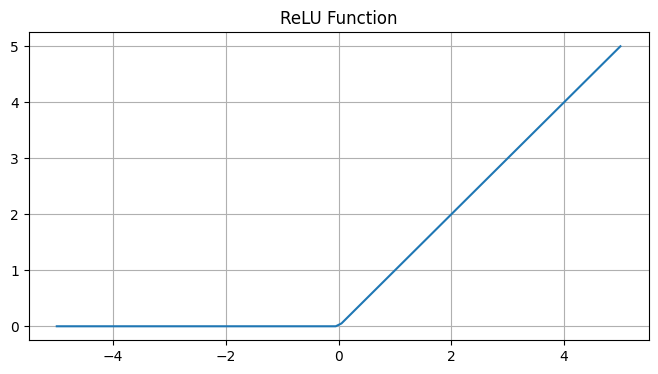

In [13]:
# Đạo hàm ReLU

x = np.linspace(-5,5,100)

y = np.maximum(0,x)

plt.figure(figsize=(8,4))
plt.plot(x,y)

plt.title("ReLU Function")
plt.grid(True)

plt.show()

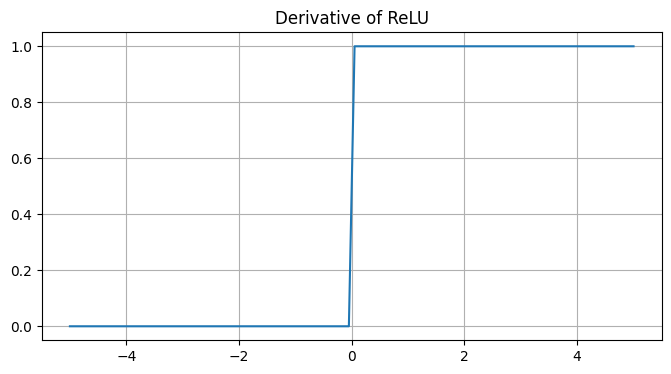

In [14]:
# Gradient
grad = np.where(
    x > 0,
    1,
    0
)

plt.figure(figsize=(8,4))
plt.plot(x,grad)

plt.title("Derivative of ReLU")
plt.grid(True)

plt.show()

In [15]:
# Test ReLU.backward()
relu = ReLU()

x = np.array([
    -2,
    3,
    -1,
    4
])

relu.forward(x)

grad_output = np.array([
    5,
    5,
    5,
    5
])

grad_input = relu.backward(
    grad_output
)

print(grad_input)

[0 5 0 5]


### Chain Rule

Giả sử:
$$z = Wx +b$$
$$a = ReLU(z)$$
$$L = Loss(a)$$

Ta nhận được:
$$\frac {\partial L} {\partial a}$$

Muốn tìm:
$$\frac {\partial L} {\partial z}$$

Áp dụng Chain Rule:
$$\frac {\partial L} {\partial z} = \frac {\partial L} {\partial a} \cdot \frac {\partial a} {\partial z}$$

In [16]:
grad_z = relu.backward(
    grad_input
)

In [18]:
# Dense + ReLU Forward
dense = Dense(
    input_dim=2,
    output_dim=3
)

relu = ReLU()

x = np.array([
    1.0,
    2.0
])

z = dense.forward(x)

a = relu.forward(z)

print(a)

[1.20567061 0.57870957 2.87491129]


In [19]:
# Dense + ReLU Backward
grad_output = np.ones(3)

# Backprop:
grad_relu = relu.backward(
    grad_output
)

grad_input = dense.backward(
    grad_relu
)

print("dW")
print(dense.dW)

print()

print("db")
print(dense.db)

print()

print("grad_input")
print(grad_input)

dW
[[1. 2.]
 [1. 2.]
 [1. 2.]]

db
[1. 1. 1.]

grad_input
[1.83239666 1.41344741]


In [20]:
# Real NN
dense1 = Dense(2,8)

relu = ReLU()

dense2 = Dense(8,1)

x = np.array([
    1.0,
    2.0
])

target = np.array([
    1.0
])

# Training Loop
losses = []

for epoch in range(100):

    z1 = dense1.forward(x)

    a1 = relu.forward(z1)

    prediction = dense2.forward(a1)

    loss = np.mean(
        (prediction-target)**2
    )

    losses.append(loss)

    grad_loss = (
        2*(prediction-target)
    )

    grad_dense2 = dense2.backward(
        grad_loss
    )

    grad_relu = relu.backward(
        grad_dense2
    )

    dense1.backward(
        grad_relu
    )

    dense2.update(0.05)
    dense1.update(0.05)

    if epoch % 10 == 0:

        print(
            epoch,
            round(float(loss),6)
        )

0 3.204418
10 0.0
20 0.0
30 0.0
40 0.0
50 0.0
60 0.0
70 0.0
80 0.0
90 0.0


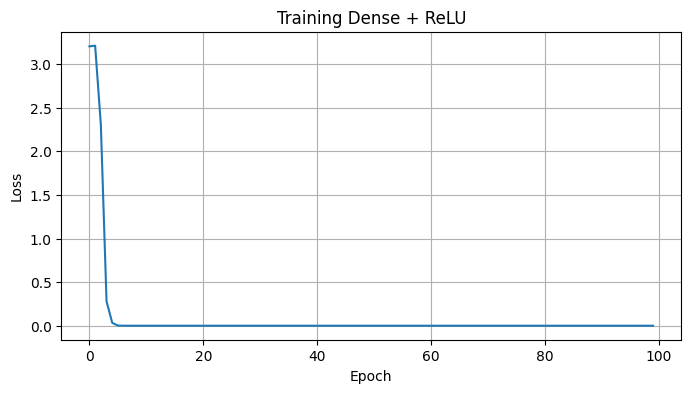

In [21]:
# Visualization
plt.figure(figsize=(8,4))

plt.plot(losses)

plt.title(
    "Training Dense + ReLU"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()